# Constitutive-reporter control — separating a **circuit switch** from a **nonlinear readout**

**Thesis.** NUDGE assumes an *affine* reporter ($\Lambda = \text{base} + \text{scale}\cdot a$).
When the true reporter is **nonlinear** (a saturating / sigmoidal Hill, $h\ge 1$), a *linear*
circuit read through it produces a pseudo-bimodal count distribution the affine-readout switch
model can only explain by **bending the circuit** — a **confident false positive**
(`NUDGE-LIM-006`, the sharpest bound on NUDGE's fail-safe guarantee). Only the composition
$R\circ g$ is observed, so from **one** population you cannot tell circuit ultrasensitivity from
measurement ultrasensitivity.

**The fix (`NUDGE-METHOD-011`).** Add a **constitutive-reporter control**: a calibration
population whose reporter is driven at **known** activity doses, *bypassing the circuit*. It
measures the reporter's transfer function directly and **anchors the readout** — using
**readout parameters only** (no circuit leak). A **profile likelihood over the circuit Hill
$n$** then decides whether the ultrasensitivity is **biological**.

**Honesty (a feature, not fine print — `NUDGE-LIM-018`).** The control lets NUDGE *reject "no
switch"* but does **NOT** point-identify the exact $n$ (the circuit's internal $K/n/v_{max}$
trade-off persists). The strongest verdict is *the switch is real*; it **never** emits a bare
threshold / gain / ceiling. It turns the confident false positive into a **correct call** or an
**honest abstention** — never a confident wrong.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from nudge.inference.constitutive import (
    ReadoutCircuitParams,
    generate_constitutive_dataset,
    calibrate_readout,
    control_loss_circuit_gradient,
    profile_circuit_n,
)

N_GRID = (1.0, 1.5, 2.0, 3.0, 5.0, 7.0)
print("ready - self-contained synthetic demo (no external data)")

ready - self-contained synthetic demo (no external data)


## 1. The setup — a real switch, hidden behind a nonlinear reporter

Ground truth: a genuine biological switch (circuit Hill $n=3$) read through a **steep**
saturating reporter ($h=6$). We observe only the reporter's counts (the composition). We also
run a **constitutive control**: the same reporter driven at 10 *known* activity doses, bypassing
the circuit.


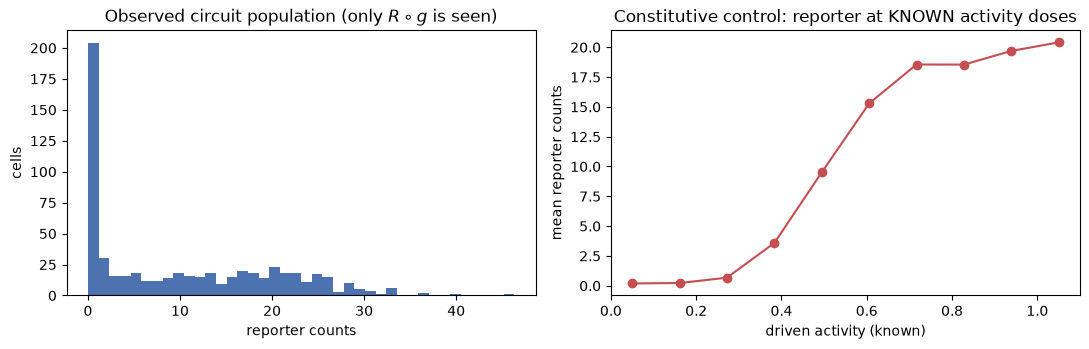

population: 600 cells, mean=10.0, sd=10.0


In [2]:
p_switch = ReadoutCircuitParams(
    k=1.0, n=3.0, vmax=1.0, basal=0.05, km=0.5, h=6.0, readout_vmax=20.0, readout_base=0.1
)
pop, control, _ = generate_constitutive_dataset(
    p_switch, n_cells=600, n_ctrl_doses=10, n_ctrl_reps=200, seed=0
)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(pop, bins=40, color="#4C72B0")
ax[0].set(title="Observed circuit population (only $R \\circ g$ is seen)",
          xlabel="reporter counts", ylabel="cells")
doses, curve = control.calibration_curve()
ax[1].plot(doses, curve, "o-", color="#C44E52")
ax[1].set(title="Constitutive control: reporter at KNOWN activity doses",
          xlabel="driven activity (known)", ylabel="mean reporter counts")
plt.tight_layout()
plt.show()
print("population: %d cells, mean=%.1f, sd=%.1f" % (pop.size, pop.mean(), pop.std()))

## 2. The control anchors the readout — using **readout parameters only**

We fit the reporter's Hill transfer function from the control (a dose-response of *known* dose
vs measured reporter). Crucially the calibration loss depends on the **readout** parameters
*only* — never the circuit's $\{K, n, v_{max}\}$. We prove it: the gradient of the control loss
with respect to **every** circuit parameter is **identically zero**.


In [3]:
calib = calibrate_readout(control, n_boot=300, seed=0)
print("calibrated reporter Hill h = %.2f  (95%% CI %.2f-%.2f, nonlinear=%s, r2=%.3f)"
      % (calib.h, calib.ci_h[0], calib.ci_h[1], calib.is_nonlinear, calib.r2))

grads = control_loss_circuit_gradient(control, p_switch)
print("gradient of the control loss w.r.t. circuit params (must all be 0):")
for name, gval in grads.items():
    print("   d(control_loss)/d(%-5s) = %.1e" % (name, gval))
assert all(gval == 0.0 for gval in grads.values()), "circuit parameter leaked into the control!"
print("PROVEN: no circuit-parameter leak - the anchor is legitimate.")

calibrated reporter Hill h = 5.97  (95% CI 4.25-7.42, nonlinear=True, r2=0.999)


gradient of the control loss w.r.t. circuit params (must all be 0):
   d(control_loss)/d(K    ) = 0.0e+00
   d(control_loss)/d(n    ) = 0.0e+00
   d(control_loss)/d(vmax ) = 0.0e+00
   d(control_loss)/d(basal) = 0.0e+00
PROVEN: no circuit-parameter leak - the anchor is legitimate.


## 3. The headline — WITHOUT a control the split is degenerate; WITH it, "no switch" is rejected

We **profile** the loss over the circuit Hill $n$: for each fixed $n$ we re-optimize everything
else. **WITHOUT** the control the profile is **FLAT** — a graded $n=1$ (no switch, all the
nonlinearity in the reporter) fits as well as the true $n=3$: *you cannot even tell a circuit
switch exists*. **WITH** the control anchoring the readout, the readout can no longer absorb the
ultrasensitivity, so $n=1$ is **REJECTED** — the profile develops a well and the data say the
switch is **biological**.


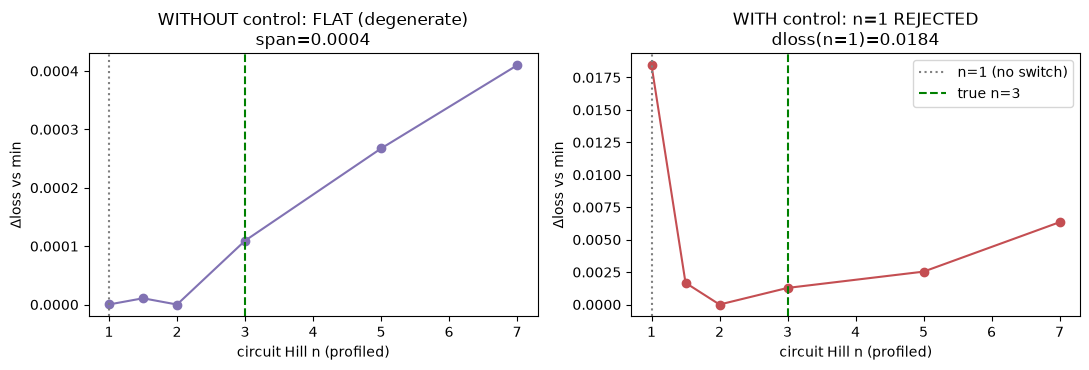

WITHOUT control : n-profile span = 0.0004   (flat => cannot tell a switch exists)
WITH    control : n=1 rejection  = 0.0184   (>> the flat span => switch is REAL)
VERDICT: BIOLOGICAL-SWITCH (confident-wrong = False )


In [4]:
res_switch = profile_circuit_n(
    pop, control, p_switch, n_grid=N_GRID,
    restarts=3, steps=600, n_model_cells=400, seed=0,
)
g = np.array(res_switch.n_grid)
lo = np.array(res_switch.loss_no_control)
hi = np.array(res_switch.loss_with_control)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(g, lo - lo.min(), "o-", color="#8172B3")
ax[0].axvline(1.0, ls=":", c="grey")
ax[0].axvline(3.0, ls="--", c="green")
ax[0].set(title="WITHOUT control: FLAT (degenerate)\nspan=%.4f" % res_switch.span_no_control,
          xlabel="circuit Hill n (profiled)", ylabel="$\\Delta$loss vs min")
ax[1].plot(g, hi - hi.min(), "o-", color="#C44E52")
ax[1].axvline(1.0, ls=":", c="grey", label="n=1 (no switch)")
ax[1].axvline(3.0, ls="--", c="green", label="true n=3")
ax[1].set(title="WITH control: n=1 REJECTED\ndloss(n=1)=%.4f" % res_switch.n1_rejection,
          xlabel="circuit Hill n (profiled)", ylabel="$\\Delta$loss vs min")
ax[1].legend()
plt.tight_layout()
plt.show()

print("WITHOUT control : n-profile span = %.4f   (flat => cannot tell a switch exists)"
      % res_switch.span_no_control)
print("WITH    control : n=1 rejection  = %.4f   (>> the flat span => switch is REAL)"
      % res_switch.n1_rejection)
print("VERDICT:", res_switch.call.upper(),
      "(confident-wrong =", res_switch.is_confident_wrong, ")")

## 4. Fail-safe — the LIM-006 hazard (a **linear** circuit) must ABSTAIN, not manufacture a switch

Now the dangerous case: a **linear** circuit ($n=1$) read through the same steep reporter. This
is *exactly* what fools the affine-readout fit into a confident false switch. With the control,
the profile does **not** reject $n=1$ (the truth) => NUDGE **abstains** (`unresolved`). The
confident false positive becomes an **honest abstention** — never a bare switch.


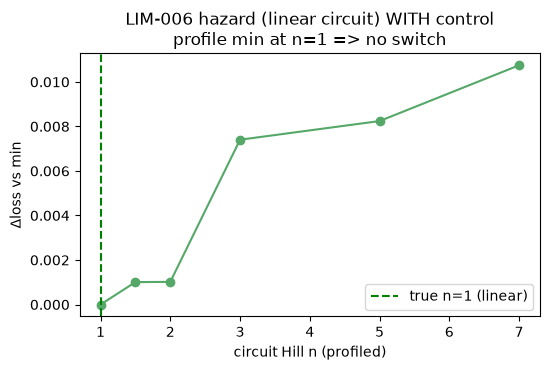

n=1 rejection = 0.0000  (~0 => cannot reject 'no switch')
VERDICT: UNRESOLVED (confident-wrong = False )


In [5]:
p_linear = ReadoutCircuitParams(
    k=1.0, n=1.0, vmax=1.0, basal=0.05, km=0.5, h=6.0, readout_vmax=20.0, readout_base=0.1
)
pop_lin, ctrl_lin, _ = generate_constitutive_dataset(
    p_linear, n_cells=600, n_ctrl_doses=10, n_ctrl_reps=200, seed=0
)
res_linear = profile_circuit_n(
    pop_lin, ctrl_lin, p_linear, n_grid=N_GRID,
    restarts=3, steps=600, n_model_cells=400, seed=0,
)
hL = np.array(res_linear.loss_with_control)

fig, ax = plt.subplots(figsize=(5.6, 3.8))
ax.plot(g, hL - hL.min(), "o-", color="#55A868")
ax.axvline(1.0, ls="--", c="green", label="true n=1 (linear)")
ax.set(title="LIM-006 hazard (linear circuit) WITH control\nprofile min at n=%g => no switch"
       % res_linear.argmin_n_with_control,
       xlabel="circuit Hill n (profiled)", ylabel="$\\Delta$loss vs min")
ax.legend()
plt.tight_layout()
plt.show()

print("n=1 rejection = %.4f  (~0 => cannot reject 'no switch')" % res_linear.n1_rejection)
print("VERDICT:", res_linear.call.upper(),
      "(confident-wrong =", res_linear.is_confident_wrong, ")")

## 5. What the demo proves (the honesty asserts)

The narrative above is only trustworthy if the code enforces it. We assert, on synthetic ground
truth: (a) a **true switch** flips to `biological-switch` with the control; (b) the **LIM-006
hazard** (a linear circuit) `abstains`; (c) **neither** is ever a confident-wrong bare mechanism;
(d) the biological-switch verdict states, in its own reason, that it does **not** point-identify
$n$ (the `NUDGE-LIM-018` caveat).


In [6]:
# (a) true switch -> biological
assert res_switch.call == "biological-switch"
assert res_switch.n1_rejection > 5.0 * res_switch.span_no_control  # the control CREATED structure
# (b) LIM-006 hazard -> honest abstention, NOT a manufactured switch
assert res_linear.call == "unresolved"
assert res_linear.argmin_n_with_control == 1.0
# (c) never a bare threshold/gain/ceiling
assert not res_switch.is_confident_wrong and not res_linear.is_confident_wrong
# (d) the honest caveat is stated loudly
assert "does NOT" in res_switch.reason and "point-identif" in res_switch.reason.lower()

print("ALL ASSERTS PASS:")
print("  true switch     ->", res_switch.call, "(reject 'no switch': the switch is BIOLOGICAL)")
print("  linear (hazard) ->", res_linear.call, "(honest abstention - no manufactured switch)")
print("  confident-wrong calls: 0")
print("  honest caveat present:  does NOT point-identify n (needs a second anchor)")

ALL ASSERTS PASS:
  true switch     -> biological-switch (reject 'no switch': the switch is BIOLOGICAL)
  linear (hazard) -> unresolved (honest abstention - no manufactured switch)
  confident-wrong calls: 0
  honest caveat present:  does NOT point-identify n (needs a second anchor)


## Reproduce it

```bash
# zero-setup demo (this notebook's story), CLI:
uv run nudge constitutive --demo --circuit-n 3    # a real switch     -> biological-switch
uv run nudge constitutive --demo --circuit-n 1    # the LIM-006 hazard -> unresolved (abstain)

# the validation harness (0 confident-wrong across seeds):
uv run python scripts/vv/constitutive_control.py
```

Via the MCP tool: `constitutive(demo=true, circuit_n=3)` returns the same verdict + both
$n$-profiles for a Claude client.

**Where it goes next.** The control rejects "no switch" but does not point-identify the knob
(`NUDGE-LIM-018`); a **second anchor** — an input titration / circuit dose-response — would pin
$n$. In the field, the control is a constitutively-driven reporter titration (an mCherry /
synthetic-barcode reporter) run alongside the screen: a concrete experimental-design suggestion,
not just a NUDGE feature (`design/CONSTITUTIVE_CONTROL.md` section 3).
